In [33]:
import importlib as il
import numpy as np
import more_itertools as mit
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as spl
import scipy.special as sss
import linetimer as lt

import gurobipy as gp

import gurobi_utils as gu
import dikin_utils as du
import plot_utils as pu

import example_loader as el
import miplib_loader as ml
import jsplib_loader as jl

status_lookup = {getattr(gp.GRB.Status, k): k for k in gp.GRB.Status.__dir__() if "A" <= k[0] <= "Z"}

%matplotlib inline

In [3]:
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

Running: 2D from bottom
   Negated 0 constraints on 2D from bottom_copy
   Retreat to: [[1.22222222]
 [2.33333333]]
Running: 2D no easy cut from bottom
   Negated 0 constraints on 2D no easy cut from bottom_copy
   Retreat to: [[3.38297872]
 [2.72340426]]
Running: 2D steep from bottom
   Negated 0 constraints on 2D steep from bottom_copy
   Retreat to: [[3.21428571]
 [3.28571429]]
Running: 2D from top
   Negated 2 constraints on 2D from top_copy
   Retreat to: [[1.22222222]
 [2.33333333]]


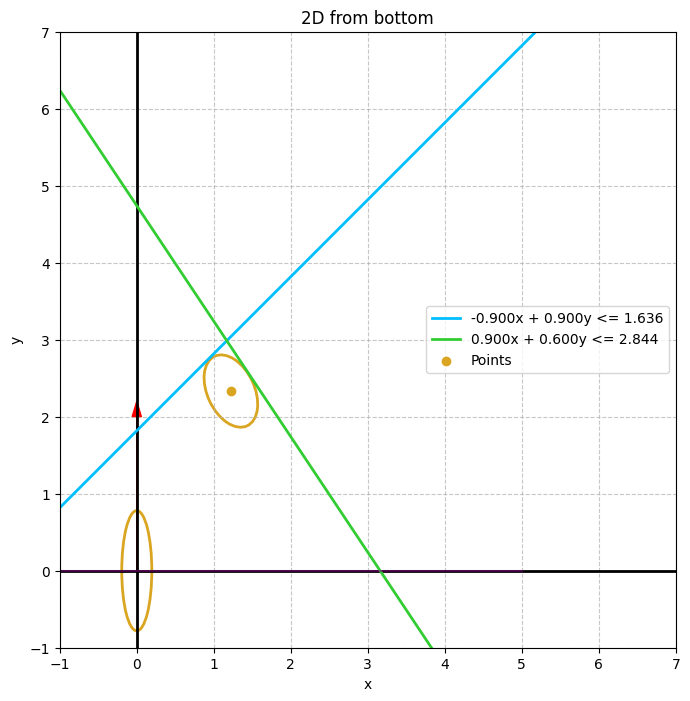

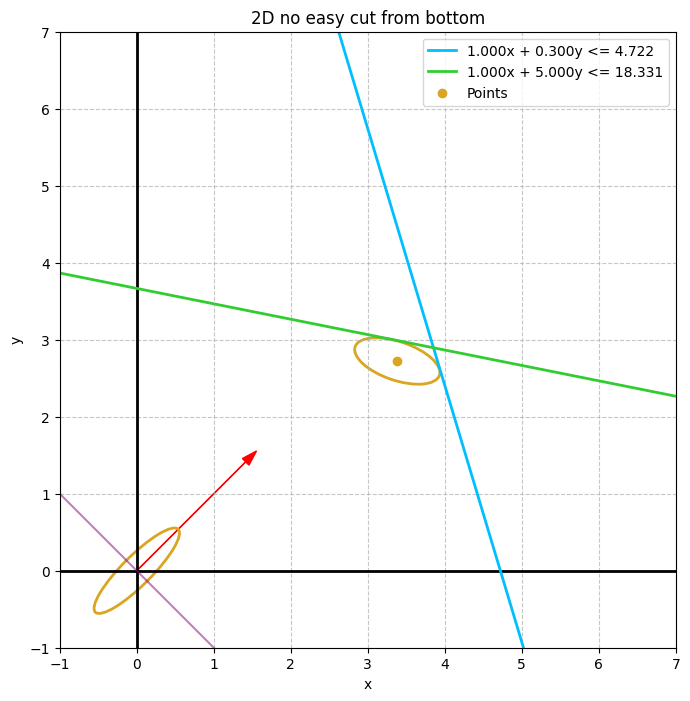

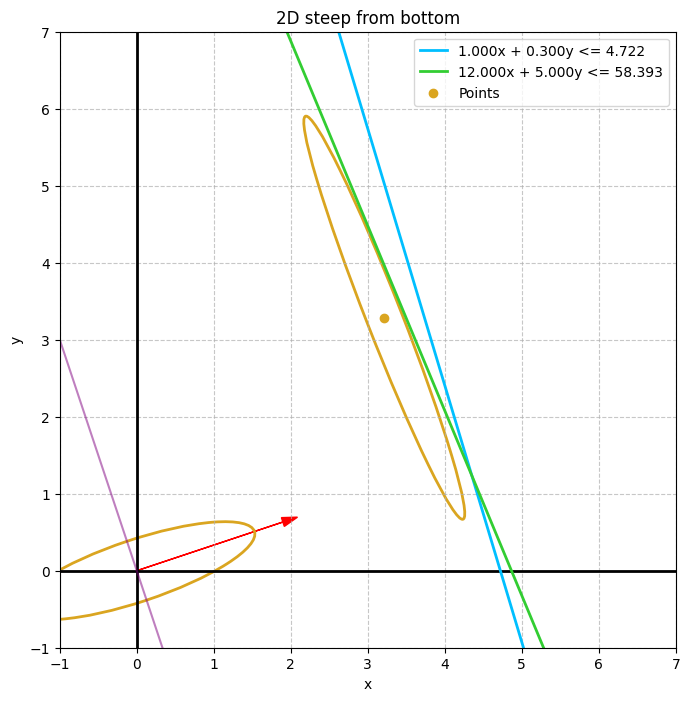

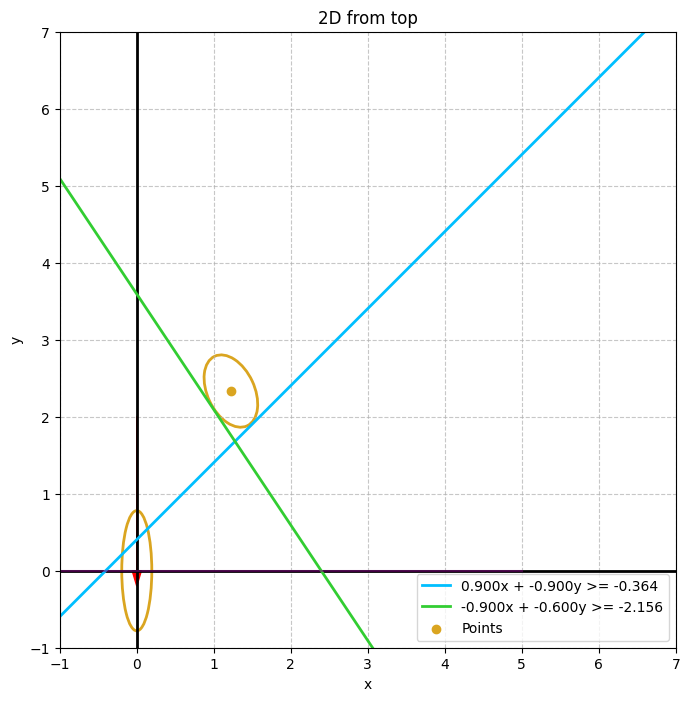

In [ ]:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

# as a test, transform to better ellipse in real nums:

def construct_U(c):
    n = len(c)
    u1 = c / np.linalg.norm(c)
    # Create a matrix with u1 as the first column, followed by identity
    A = np.eye(n)
    A[:, 0] = u1
    Q, _ = np.linalg.qr(A)
    # If QR flipped the sign of the first vector, undo it
    if np.sign(Q[:,0] @ u1) < 0:
        Q[:,0] *= -1
    return Q

def householder_U(c):
    n = len(c)
    c = c / np.linalg.norm(c)
    e1 = np.zeros_like(c)
    e1[0] = 1.0
    v = c - e1
    v = v / np.linalg.norm(v)
    H = np.eye(n) - 2.0 * np.outer(v, v)
    # Now H @ c = e1, so H^T aligns e1 to c
    return H.T

def c_aligned_slenderizer(A, b, c, l, u, x):
    H = du.compute_H(A, b, l, u, x)
    # Compute the Cholesky factorization of H
    # L = np.linalg.cholesky(H)
    # H2 = np.linalg.inv(L.T).real
    # H2 = spl.sqrtm(H).real
    # H2 = np.linalg.inv(H2).real
    # return H2  # for making it round:
    l1 = 1/4.0
    l2 = 1

    # D = np.diag([l2] * (c.shape[0] - 1) + [l1])
    # U = construct_U(c.flatten())

    # Build H^(-1/2) -- same has sqrtm + inv above
    eigvals, eigvecs = np.linalg.eigh(H)  # is this better than sqrtm?
    H2 = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    # return U @ D @ U.T @ H2
    # try gemini's approach:
    T = l2 * np.eye(c.shape[0]) + (l1 - l2) * (c @ c.T) / (c.T @ c)
    return T @ H2


instances = el.get_instances(env)
for instance in list(instances.values())[0:4]:
    model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName)
    niv = model.NumIntVars
    _, _ = gu.relax_int_or_bin_to_continuous(model)
    model.optimize()
    x1 = np.array([v.X for v in model.getVars()]).reshape(-1, 1)

    model2 = gu.relax_and_grow(model, x1, 1)

    gu.standardize_gt_to_lt(model2)
    A, b, c, lb, ub = get_A_b_c_l_u(model2)

    print("   Retreat to:", x1)
    senses = np.array(model.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, lb, ub, senses, points=[x1[:2, 0].flatten()])
    _, H1 = du.plot_ellipse(A, b, lb, ub, x1, fig=fig)
    du.plot_objective(c, model.ModelSense == gp.GRB.MINIMIZE, fig=fig)

    T = c_aligned_slenderizer(A, b, c, lb, ub, x1)
    H2 = T @ H1 @ T.T
    Vol1 = np.linalg.det(H1)
    Vol2 = np.linalg.det(H2)
    scalar = (Vol1 / Vol2) ** (0.5 / H1.shape[0])
    # H2 = (Vol1 / Vol2) ** (1.0 / H1.shape[0]) * H2

    model3 = gu.substitute(model2, scalar * T.T, x1)  # of course, changing to unimodular will fix need of scalar
    A, b, _, lb, ub = gu.get_A_b_c_l_u(model3)

    du.plot_ellipse(A, b, lb, ub, np.zeros_like(x1), fig=fig)
    # du.plot_ellipse(T @ A, T @ b, T @ lb, ub2, x1, fig=fig)
